<a href="https://colab.research.google.com/github/aapaul29/Distance-Recognition-SML1-/blob/aaryan-workspace/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SML Project 1**

This notebook works in both **VS Code (local)** and **Google Colab**.

## **1. <u>Environment Detection & Setup</u>**

In [22]:
import sys
import os

IN_COLAB = 'google.colab' in sys.modules
print(f"Running in {'Google Colab' if IN_COLAB else 'VS Code / local'}")

Running in VS Code / local




## **2. <u>Google Colab: Mount Drive & Navigate to Project</u>**
This cell only runs on Colab. Adjust `COLAB_PROJECT_PATH` to where you uploaded the project folder in your Google Drive.

In [2]:
# ---------------------------------------------------------------
# COLAB ONLY â€” skip if running locally
# Adjust this path to match your Google Drive folder structure.
COLAB_PROJECT_PATH = "/content/drive/MyDrive/Aaryan/Uni/BS-Mech-Eng-ETH-Zurich/2nd-year/Semester-4/Stochastics&Machine-Learning/Distance-Recognition-SML1-"
# ---------------------------------------------------------------

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd "$COLAB_PROJECT_PATH"
    print(f"Working directory: {os.getcwd()}")

    # Unzip data if not already extracted
    data_zip = os.path.join(COLAB_PROJECT_PATH, "data.zip")
    data_dir = os.path.join(COLAB_PROJECT_PATH, "data")
    if os.path.exists(data_zip) and not os.path.exists(data_dir):
        print("Unzipping data...")
        os.makedirs(data_dir, exist_ok=True)
        !unzip -q $data_zip -d $data_dir
        print("Done.")
    else:
        print("Data directory already exists or no zip found â€” skipping unzip.")
else:
    print("Local environment â€” no mounting needed.")

Local environment â€” no mounting needed.


## **3. <u>Auto-reload & Imports</u>**

In [3]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Memory
from scipy.stats import uniform, randint

# Sklearn imports
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    ExtraTreesRegressor,
    StackingRegressor,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

# skimage intentionally NOT imported â€” HOG implemented manually with NumPy below

from utils import load_config, load_dataset, load_test_dataset, print_results, save_results

config = load_config()

[INFO]: Configs are loaded with: 
 {'data_dir': WindowsPath('data'), 'load_rgb': True, 'downsample_factor': 2}


In [4]:
if IN_COLAB:
    import shutil
    from pathlib import Path
    src = "/content/drive/MyDrive/Aaryan/Uni/BS-Mech-Eng-ETH-Zurich/2nd-year/Semester-4/Stochastics&Machine-Learning/Distance-Recognition-SML1-/data"
    dst = "/content/data"
    if not Path(dst).exists():
        print("Copying data to local Colab storage (faster I/O)...")
        shutil.copytree(src, dst)
        print("Done.")
    else:
        print("Local data already exists â€” skipping copy.")
    config["data_dir"] = Path(dst)
else:
    print("Running locally-copying not needed")

Running locally-copying not needed


In [5]:
# â”€â”€ Load Dataset â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
images, distances = load_dataset(config)
images = np.array(images)
print(f"[INFO]: Loaded {len(images)} images, shape: {images.shape}")

[INFO]: Loaded 3000 images, shape: (3000, 67500)


## 6. Feature Engineering & Model (0.1035 m Kaggle submission)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np, time

ds = config["downsample_factor"]
H = W = 300 // ds
C = 3 if config["load_rgb"] else 1
print(f"Image size: {H}x{W}, channels: {C}")

def to_gray(img_flat):
    if C == 3:
        return img_flat.reshape(H, W, 3).mean(axis=2).astype(np.float32)
    return img_flat.reshape(H, W).astype(np.float32)

def sobel_axis1(img):
    p = np.pad(img, 1, mode='reflect')
    return (-p[0:-2,0:-2] - 2*p[1:-1,0:-2] - p[2:,0:-2]
            + p[0:-2,2:]  + 2*p[1:-1,2:]   + p[2:,2:]).astype(np.float32)

def sobel_axis0(img):
    p = np.pad(img, 1, mode='reflect')
    return (-p[0:-2,0:-2] - 2*p[0:-2,1:-1] - p[0:-2,2:]
            + p[2:,0:-2]  + 2*p[2:,1:-1]   + p[2:,2:]).astype(np.float32)

def extract_lbp(img_2d):
    lbp = np.zeros_like(img_2d, dtype=np.uint8)
    center = img_2d[1:-1, 1:-1]
    for i, n in enumerate([
        img_2d[0:-2,0:-2], img_2d[0:-2,1:-1], img_2d[0:-2,2:],
        img_2d[1:-1,2:],   img_2d[2:,2:],     img_2d[2:,1:-1],
        img_2d[2:,0:-2],   img_2d[1:-1,0:-2]
    ]):
        lbp[1:-1,1:-1] += (n >= center).astype(np.uint8) * (2**i)
    hist, _ = np.histogram(lbp, bins=32, range=(0,256))
    return hist.astype(np.float32) / (hist.sum() + 1e-8)

def extract_all_features(X_raw, H, W, C):
    all_feat = []
    for img in X_raw:
        gray = to_gray(img)
        wt = np.linspace(0.3, 1.0, H).reshape(-1, 1)
        img_w = gray * wt
        feats = []

        for g in [4, 5]:
            gh, gw = H // g, W // g
            for i in range(g):
                for j in range(g):
                    c = img_w[i*gh:(i+1)*gh, j*gw:(j+1)*gw]
                    feats.extend([c.mean(), c.var()])

        n_strips = 25
        sh = H // n_strips
        means = []
        for i in range(n_strips):
            s = img_w[i*sh:(i+1)*sh, :]
            m = s.mean(); means.append(m)
            feats.extend([m, s.var(), s.min(), s.max()])
        for i in range(1, n_strips):
            feats.append(means[i] - means[i-1])

        row_means = gray.mean(axis=1)
        vg = np.diff(row_means)
        feats.extend([vg.mean(), vg.std(), vg.min(), vg.max()])
        feats.append(np.argmax(np.abs(vg)) / H)
        feats.append(np.argmin(vg) / H)
        feats.append(np.argmax(row_means) / H)
        feats.append(np.argmin(row_means) / H)
        for p in [25, 50, 75]:
            feats.append(np.percentile(row_means, p))
        feats.append(row_means[:H//3].mean() - row_means[2*H//3:].mean())

        bt = 2*H//3
        bot = img_w[bt:, :]
        bh = (H - bt) // 4; bw = W // 4
        if bh > 0:
            for i in range(4):
                for j in range(4):
                    c = bot[i*bh:(i+1)*bh, j*bw:(j+1)*bw]
                    feats.extend([c.mean(), c.var()])

        hg, _ = np.histogram(gray, bins=16, range=(0,255))
        feats.extend((hg/(hg.sum()+1e-8)).tolist())

        feats.extend([gray.mean(), gray.std(), gray.var()])
        for p in [5,10,25,50,75,90,95]:
            feats.append(np.percentile(gray, p))
        feats.append(gray[H//2:].mean() / (gray[:H//2].mean()+1e-8))
        feats.append(gray[:H//3].mean() / (gray[2*H//3:].mean()+1e-8))
        feats.append(gray[2*H//3:].std() / (gray[:H//3].std()+1e-8))

        feats.extend(extract_lbp(gray).tolist())

        sx = sobel_axis1(img_w); sy = sobel_axis0(img_w)
        feats.extend([sx.mean(), sx.var(), sy.mean(), sy.var()])
        hsx, _ = np.histogram(sx, bins=16)
        hsy, _ = np.histogram(sy, bins=16)
        feats.extend((hsx/(hsx.sum()+1e-8)).tolist())
        feats.extend((hsy/(hsy.sum()+1e-8)).tolist())

        grad = np.abs(np.diff(gray, axis=0))
        for t in [3,5,8,10,15,20,25,35]:
            rows = np.where(grad > t, np.arange(H-1).reshape(-1,1), -1).max(axis=0)
            v = np.where(rows >= 0, rows / H, 0).astype(np.float32)
            valid = v[v > 0]
            if len(valid) > 0:
                feats.extend([np.median(valid), np.mean(valid), np.std(valid),
                              np.percentile(valid,25), np.percentile(valid,75)])
            else:
                feats.extend([0,0,0,0,0])

        mag = np.sqrt(sx**2 + sy**2)
        zh = H // 10
        for i in range(10):
            zone = mag[i*zh:(i+1)*zh]
            feats.extend([zone.mean(), zone.var()])

        col_means = gray.mean(axis=0)
        cg = np.diff(col_means)
        feats.extend([col_means.mean(), col_means.std(), cg.mean(), cg.std()])
        feats.append(gray[:,:W//2].mean() / (gray[:,W//2:].mean()+1e-8))
        for p in [10,25,50,75,90]:
            feats.append(np.percentile(np.min(gray, axis=0), p))
        for p in [10,25,50,75,90]:
            feats.append(np.percentile(gray[H//2:].mean(axis=0), p))

        if C == 3:
            img_rgb = img.reshape(H,W,3).astype(np.float32)
            r,g,b = img_rgb[:,:,0], img_rgb[:,:,1], img_rgb[:,:,2]
            for ch in [r,g,b]:
                feats.extend([ch.mean(), ch.std()])
            feats.extend([r.mean()/(g.mean()+1e-8), r.mean()/(b.mean()+1e-8), g.mean()/(b.mean()+1e-8)])
            for ch in [r,g,b]:
                feats.append(ch[H//2:].mean()/(ch[:H//2].mean()+1e-8))
            for ch in [r,g,b]:
                hc, _ = np.histogram(ch, bins=16, range=(0,255))
                feats.extend((hc/(hc.sum()+1e-8)).tolist())
            sh10 = H // 10
            for ch in [r,g,b]:
                for i in range(10):
                    feats.append(ch[i*sh10:(i+1)*sh10].mean())
            for ch in [r,g,b]:
                feats.append(ch[2*H//3:].mean() / (ch[:H//3].mean()+1e-8))

        all_feat.append(np.array(feats, dtype=np.float32))
    return np.array(all_feat)

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    images, distances, test_size=0.15, random_state=42
)

t0 = time.time()
X_train_hand = extract_all_features(X_train_raw, H, W, C)
X_val_hand   = extract_all_features(X_val_raw,   H, W, C)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_hand)
X_val_s   = scaler.transform(X_val_hand)
print(f"Done ({time.time()-t0:.1f}s), features: {X_train_s.shape[1]}")

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import mean_absolute_error
from sklearn.base import BaseEstimator, RegressorMixin

class HGBClf(BaseEstimator, RegressorMixin):
    def __init__(self, n_bins=30, **kwargs):
        self.n_bins = n_bins
        self.kwargs = kwargs
    def fit(self, X, y):
        edges = np.linspace(y.min()-0.01, y.max()+0.01, self.n_bins+1)
        self.centers_ = (edges[:-1] + edges[1:]) / 2
        yb = np.clip(np.digitize(y, edges)-1, 0, self.n_bins-1)
        self.clf_ = HistGradientBoostingClassifier(**self.kwargs)
        self.clf_.fit(X, yb)
        self.cc_ = self.centers_[self.clf_.classes_]
        return self
    def predict(self, X):
        return self.clf_.predict_proba(X) @ self.cc_

knn2 = KNeighborsRegressor(n_neighbors=2, weights='distance')
knn2.fit(X_train_s, y_train)
knn1 = KNeighborsRegressor(n_neighbors=1)
knn1.fit(X_train_s, y_train)
knn3 = KNeighborsRegressor(n_neighbors=3, weights='distance')
knn3.fit(X_train_s, y_train)

print("Training classifier...")
clf = HGBClf(n_bins=15, max_iter=500, max_depth=5, learning_rate=0.05,
             min_samples_leaf=15, l2_regularization=0.2, random_state=42)
clf.fit(X_train_s, y_train)

p_knn2  = knn2.predict(X_val_s)
p_knn13 = 0.5 * knn1.predict(X_val_s) + 0.5 * knn3.predict(X_val_s)
p_clf   = clf.predict(X_val_s)

# Fixed blend weights: 0.20 KNN-2 + 0.49 avg(KNN-1, KNN-3) + 0.31 HGBClf
val_pred = 0.20*p_knn2 + 0.49*p_knn13 + 0.31*p_clf

print(f"KNN k=2:    {mean_absolute_error(y_val, p_knn2)*100:.2f} cm")
print(f"KNN(1+3)/2: {mean_absolute_error(y_val, p_knn13)*100:.2f} cm")
print(f"Classifier: {mean_absolute_error(y_val, p_clf)*100:.2f} cm")
print(f"Blend:      {mean_absolute_error(y_val, val_pred)*100:.2f} cm")

In [ ]:
print("=== Validation Set ===")
print_results(y_val, val_pred)

In [ ]:
print("Retraining on all 3000 samples...")
X_all_hand = extract_all_features(images, H, W, C)
sc_f = StandardScaler()
X_all_s = sc_f.fit_transform(X_all_hand)

knn2_f = KNeighborsRegressor(n_neighbors=2, weights='distance')
knn2_f.fit(X_all_s, distances)
knn1_f = KNeighborsRegressor(n_neighbors=1)
knn1_f.fit(X_all_s, distances)
knn3_f = KNeighborsRegressor(n_neighbors=3, weights='distance')
knn3_f.fit(X_all_s, distances)

print("Training classifier...")
clf_f = HGBClf(n_bins=15, max_iter=500, max_depth=5, learning_rate=0.05,
               min_samples_leaf=15, l2_regularization=0.2, random_state=42)
clf_f.fit(X_all_s, distances)

test_raw    = np.array(load_test_dataset(config))
X_test_hand = extract_all_features(test_raw, H, W, C)
X_test_s    = sc_f.transform(X_test_hand)

t_knn2  = knn2_f.predict(X_test_s)
t_knn13 = 0.5 * knn1_f.predict(X_test_s) + 0.5 * knn3_f.predict(X_test_s)
t_clf   = clf_f.predict(X_test_s)

test_pred = 0.20*t_knn2 + 0.49*t_knn13 + 0.31*t_clf
test_pred = np.clip(test_pred, 0.1, 4.0)
save_results(test_pred)
print(f"Saved! Range: {test_pred.min():.3f} - {test_pred.max():.3f} m")

In [11]:
# â”€â”€ Feature Engineering â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
print("\n" + "="*60)
print("  FEATURE ENGINEERING")
print("="*60)
X_all = get_cached_features(images, config, "train")


  FEATURE ENGINEERING
[CACHE]: Computing/loading train features...
[INFO]: Image dimensions: 150x150x3
[INFO]: HOG pixels_per_cell: (12, 12)
[INFO]: Extracting HOG features...
[INFO]: HOG features: 4356 (took 29.4s)
[INFO]: Extracting spatial statistics...
[INFO]: Spatial features: 69
[INFO]: Extracting color histograms...
[INFO]: Color histogram features: 96
[INFO]: Combined features: 4521


c:\Users\aarya\OneDrive\Desktop\Distance-Recognition-SML1-\.venv\Lib\site-packages\joblib\_store_backends.py:226: CacheWarning: Unable to cache to disk. Possibly a race condition in the creation of the directory. Exception: [Errno 2] No such file or directory: 'c:\\Users\\aarya\\OneDrive\\Desktop\\Distance-Recognition-SML1-\\feature_cache\\joblib\\__main__-C%3A-Users-aarya-AppData-Local-Temp-ipykernel-4186045229\\_compute_features\\7f51c894c0188a7d032b1211681391ab\\output.pkl.9b16c2526d2240459dd23a27606264a0-38904-2733141778704'.
  warnings.warn(


## **4. <u>ML Model Implementation</u>**
Implement preprocessing, model training, data split and evaluation.

In [14]:
# Split on X_all (engineered features), not raw images
# First split off the test set (15%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
        X_all, distances,
        test_size=0.15,
        random_state=42)

# Then split the remaining 85% into train (~70%) and val (~15%)
# 0.15 / 0.85 â‰ˆ 0.176 â†’ gives ~15% of total as validation
X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval,
        test_size=0.176,
        random_state=42)

print(f"[INFO]: Split sizes â€” train: {len(X_train)}, "
      f"val: {len(X_val)}, test: {len(X_test)}")

[INFO]: Split sizes â€” train: 2101, val: 449, test: 450


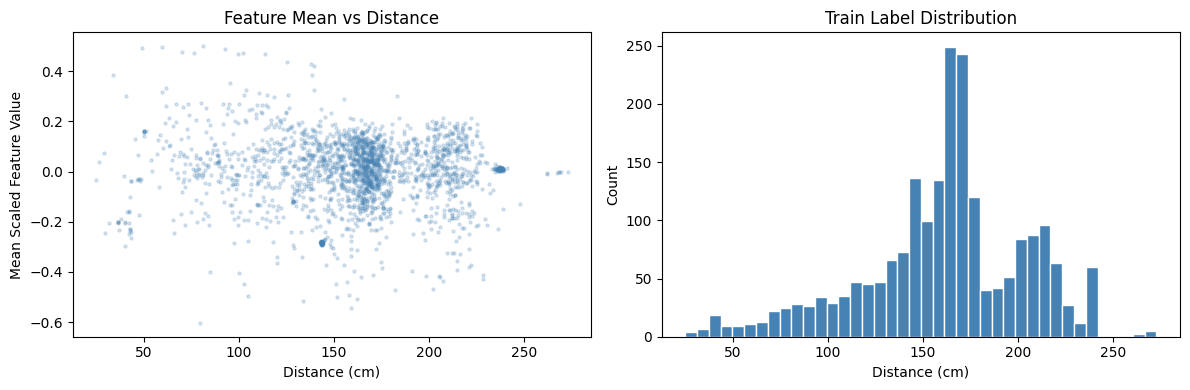

[INFO]: Training on 4521 features per sample.


In [18]:
# Quick depth-cue sanity check: mean pixel intensity vs distance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

mean_intensity = X_train_scaled.mean(axis=1)
axes[0].scatter(y_train * 100, mean_intensity, alpha=0.2, s=5, color='steelblue')
axes[0].set_xlabel('Distance (cm)')
axes[0].set_ylabel('Mean Scaled Feature Value')
axes[0].set_title('Feature Mean vs Distance')

axes[1].hist(y_train * 100, bins=40, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Distance (cm)')
axes[1].set_ylabel('Count')
axes[1].set_title('Train Label Distribution')

plt.tight_layout()
plt.show()
print(f"[INFO]: Training on {X_train_scaled.shape[1]} features per sample.")

In [21]:
# â”€â”€ HGBR with good fixed params (trains on raw scaled features â€” no PCA needed) â”€â”€
hgbr = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=800,
    max_depth=8,
    min_samples_leaf=10,
    l2_regularization=0.1,
    max_leaf_nodes=63,
    random_state=42,
)
hgbr.fit(X_train_scaled, y_train)
val_pred_hgbr = hgbr.predict(X_val_scaled)
mae_hgbr = mean_absolute_error(y_val, val_pred_hgbr) * 100
r2_hgbr  = r2_score(y_val, val_pred_hgbr) * 100
print(f"HGBR (fixed params) â€” Val MAE: {mae_hgbr:.2f} cm  |  RÂ²: {r2_hgbr:.1f}%")

KeyboardInterrupt: 

In [19]:
# â”€â”€ KNN wrapped in Pipeline(PCA â†’ KNN) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# KNN needs low-dimensional input due to curse of dimensionality, so we apply
# PCA inside the pipeline. This way the stacking ensemble can pass scaled
# features uniformly to all base learners.
print("[INFO]: Tuning KNN (PCA + KNeighbors pipeline)...")

N_PCA_KNN = 200
best_knn_mae = float('inf')
best_k        = 5
best_weights  = 'distance'

for k in [3, 5, 7, 9, 11, 15, 20]:
    for w in ['uniform', 'distance']:
        pipe = Pipeline([
            ('pca', PCA(n_components=N_PCA_KNN, random_state=42)),
            ('knn', KNeighborsRegressor(n_neighbors=k, weights=w, n_jobs=-1)),
        ])
        pipe.fit(X_train_scaled, y_train)
        mae = mean_absolute_error(y_val, pipe.predict(X_val_scaled)) * 100
        if mae < best_knn_mae:
            best_knn_mae = mae
            best_k       = k
            best_weights = w

print(f"Best KNN params: k={best_k}, weights='{best_weights}'")

best_knn_pipe = Pipeline([
    ('pca', PCA(n_components=N_PCA_KNN, random_state=42)),
    ('knn', KNeighborsRegressor(n_neighbors=best_k, weights=best_weights, n_jobs=-1)),
])
best_knn_pipe.fit(X_train_scaled, y_train)
val_pred_knn = best_knn_pipe.predict(X_val_scaled)
mae_knn = mean_absolute_error(y_val, val_pred_knn) * 100
r2_knn  = r2_score(y_val, val_pred_knn) * 100
print(f"KNN (k={best_k}, {best_weights}) â€” Val MAE: {mae_knn:.2f} cm  |  RÂ²: {r2_knn:.1f}%")

[INFO]: Tuning KNN (PCA + KNeighbors pipeline)...
Best KNN params: k=3, weights='distance'
KNN (k=3, distance) â€” Val MAE: 13.57 cm  |  RÂ²: 69.5%


In [ ]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.ensemble import HistGradientBoostingClassifier

class SoftHGBClassifier(BaseEstimator, RegressorMixin):
    """
    HGBC wrapper for regression via ordinal classification.
    Bins y into n_bins classes, trains HGBC, then predicts
    E[y] = probability-weighted bin centres (soft prediction).
    Works as a drop-in regressor in StackingRegressor.
    """
    def __init__(self, n_bins=30, learning_rate=0.05, max_iter=500,
                 max_depth=8, min_samples_leaf=10, l2_regularization=0.1,
                 max_leaf_nodes=63, random_state=42):
        self.n_bins = n_bins
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.l2_regularization = l2_regularization
        self.max_leaf_nodes = max_leaf_nodes
        self.random_state = random_state

    def fit(self, X, y):
        _, self.bin_edges_ = np.histogram(y, bins=self.n_bins)
        self.bin_centers_ = 0.5 * (self.bin_edges_[:-1] + self.bin_edges_[1:])
        # np.digitize with interior edges gives indices 0..n_bins-1
        y_cls = np.digitize(y, self.bin_edges_[1:-1])
        self.clf_ = HistGradientBoostingClassifier(
            learning_rate=self.learning_rate,
            max_iter=self.max_iter,
            max_depth=self.max_depth,
            min_samples_leaf=self.min_samples_leaf,
            l2_regularization=self.l2_regularization,
            max_leaf_nodes=self.max_leaf_nodes,
            random_state=self.random_state,
        )
        self.clf_.fit(X, y_cls)
        return self

    def predict(self, X):
        proba = self.clf_.predict_proba(X)           # (n, n_classes)
        return proba @ self.bin_centers_[self.clf_.classes_]


# -- Standalone HGBC benchmark ------------------------------------------------
print("[INFO]: Training HGBC (soft classifier regression, 30 bins)...")
hgbc = SoftHGBClassifier(n_bins=30, random_state=42)
hgbc.fit(X_train_scaled, y_train)
val_pred_hgbc = hgbc.predict(X_val_scaled)
mae_hgbc = mean_absolute_error(y_val, val_pred_hgbc) * 100
r2_hgbc  = r2_score(y_val, val_pred_hgbc) * 100
print(f"HGBC (soft) -- Val MAE: {mae_hgbc:.2f} cm  |  R2: {r2_hgbc:.1f}%")

[INFO]: Training HGBC (soft classifier regression, 30 bins)...


In [ ]:
# -- Model Comparison ----------------------------------------------------------
results = {
    'Ridge (baseline)':    mae_ridge,
    'HGBR (fixed params)': mae_hgbr,
    'HGBR (tuned)':        mae_best,
    'ExtraTrees':          mae_etr,
    f'KNN (k={best_k})':   mae_knn,
    'MLP (PCA+MLP)':       mae_mlp,
    'HGBC (soft)':         mae_hgbc,
    'Stacking':            mae_stack,
}

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#aac4e0'] * len(results)
bars = ax.barh(list(results.keys()), list(results.values()), color=colors)
ax.axvline(28, color='orange', linestyle='--', label='Grade 1.0 (28 cm)')
ax.axvline(18, color='gold',   linestyle='--', label='Grade 4.0 (18 cm)')
ax.axvline(8,  color='green',  linestyle='--', label='Grade 6.0 (8 cm)')
ax.set_xlabel('Val MAE (cm)')
ax.set_title('Model Comparison on Validation Set')
ax.legend()
for bar, val in zip(bars, results.values()):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f} cm', va='center')
plt.tight_layout()
plt.show()

In [ ]:
# -- Range-routing model ------------------------------------------------------
# Two-stage prediction to sidestep the circularity problem:
#   Stage 1: scout (best_hgbr) gives a fast initial distance estimate.
#   Stage 2: each sample is dispatched to the specialist model for its range.
#
# ROUTE_BREAKPOINTS (metres): adjust based on the per-range analysis above.
# Example: if HGBC wins 0-20cm and stacking wins 20cm+, set [0.20].
# Start with the quantile boundaries that showed the clearest model switches.

ROUTE_BREAKPOINTS = [quantiles[1], quantiles[2], quantiles[3], quantiles[4]]

# Assign a trained model to each range (0..len(breakpoints)).
# Update this list after reading the analysis — one entry per range.
route_models = [
    best_hgbr,   # range 0: closest quintile
    best_hgbr,   # range 1
    stack,       # range 2: mid range
    stack,       # range 3
    stack,       # range 4: furthest quintile
]


def route_predict(X_scaled, scout, breakpoints, models):
    """
    Vectorised two-stage prediction.
    scout  : already-fitted regressor used to estimate the range.
    models : list of fitted regressors, one per range bin.
    """
    initial = scout.predict(X_scaled)
    bins    = np.digitize(initial, breakpoints)   # 0..len(models)-1
    final   = np.empty(len(X_scaled))
    for bin_idx, model in enumerate(models):
        mask = bins == bin_idx
        if mask.any():
            final[mask] = model.predict(X_scaled[mask])
    return final


val_pred_routed = route_predict(X_val_scaled, best_hgbr, ROUTE_BREAKPOINTS, route_models)
mae_routed = mean_absolute_error(y_val, val_pred_routed) * 100
r2_routed  = r2_score(y_val, val_pred_routed) * 100
print(f"Routed     -- Val MAE: {mae_routed:.2f} cm  |  R2: {r2_routed:.1f}%")
print(f"Stacking   -- Val MAE: {mae_stack:.2f} cm")
print(f"Delta: {mae_stack - mae_routed:+.2f} cm  ({'routing wins' if mae_routed < mae_stack else 'stacking wins'})")

In [ ]:
# -- Local test-set evaluation ------------------------------------------------
final_model = None ## select best model
test_pred = final_model.predict(X_test_scaled)
mae_test  = mean_absolute_error(y_test, test_pred) * 100
r2_test   = r2_score(y_test, test_pred) * 100
print(f"Final model -- Local Test MAE: {mae_test:.2f} cm  |  R2: {r2_test:.1f}%")

# -- Retrain on FULL labelled dataset + generate Kaggle submission ------------
X_all_scaled = scaler.fit_transform(X_all)   # refit scaler on all labelled data
final_model.fit(X_all_scaled, distances)
print("Final model retrained on full labelled dataset")

# -- Load, engineer features, and transform Kaggle test images ----------------
kaggle_images_raw = load_test_dataset(config)
kaggle_images_raw = np.array(kaggle_images_raw)

kaggle_features = get_cached_features(kaggle_images_raw, config, "test")
kaggle_scaled   = scaler.transform(kaggle_features)   # transform only, never refit

kaggle_pred = final_model.predict(kaggle_scaled)

save_results(kaggle_pred)
print(f"Saved prediction.csv with {len(kaggle_pred)} predictions")
print(f"Predicted distance range: {kaggle_pred.min():.2f} m -- {kaggle_pred.max():.2f} m")